# Kaggle Space Titanic prediction quest  by 김민수

기본 세팅 : 라이브러리 호출 및 데이터 로드

In [46]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/space_titanic')

train_data_path = os.path.join(data_dir, 'train.csv')
test_data_path = os.path.join(data_dir, 'test.csv')  

Train 데이터 null 여부 체크

<Axes: >

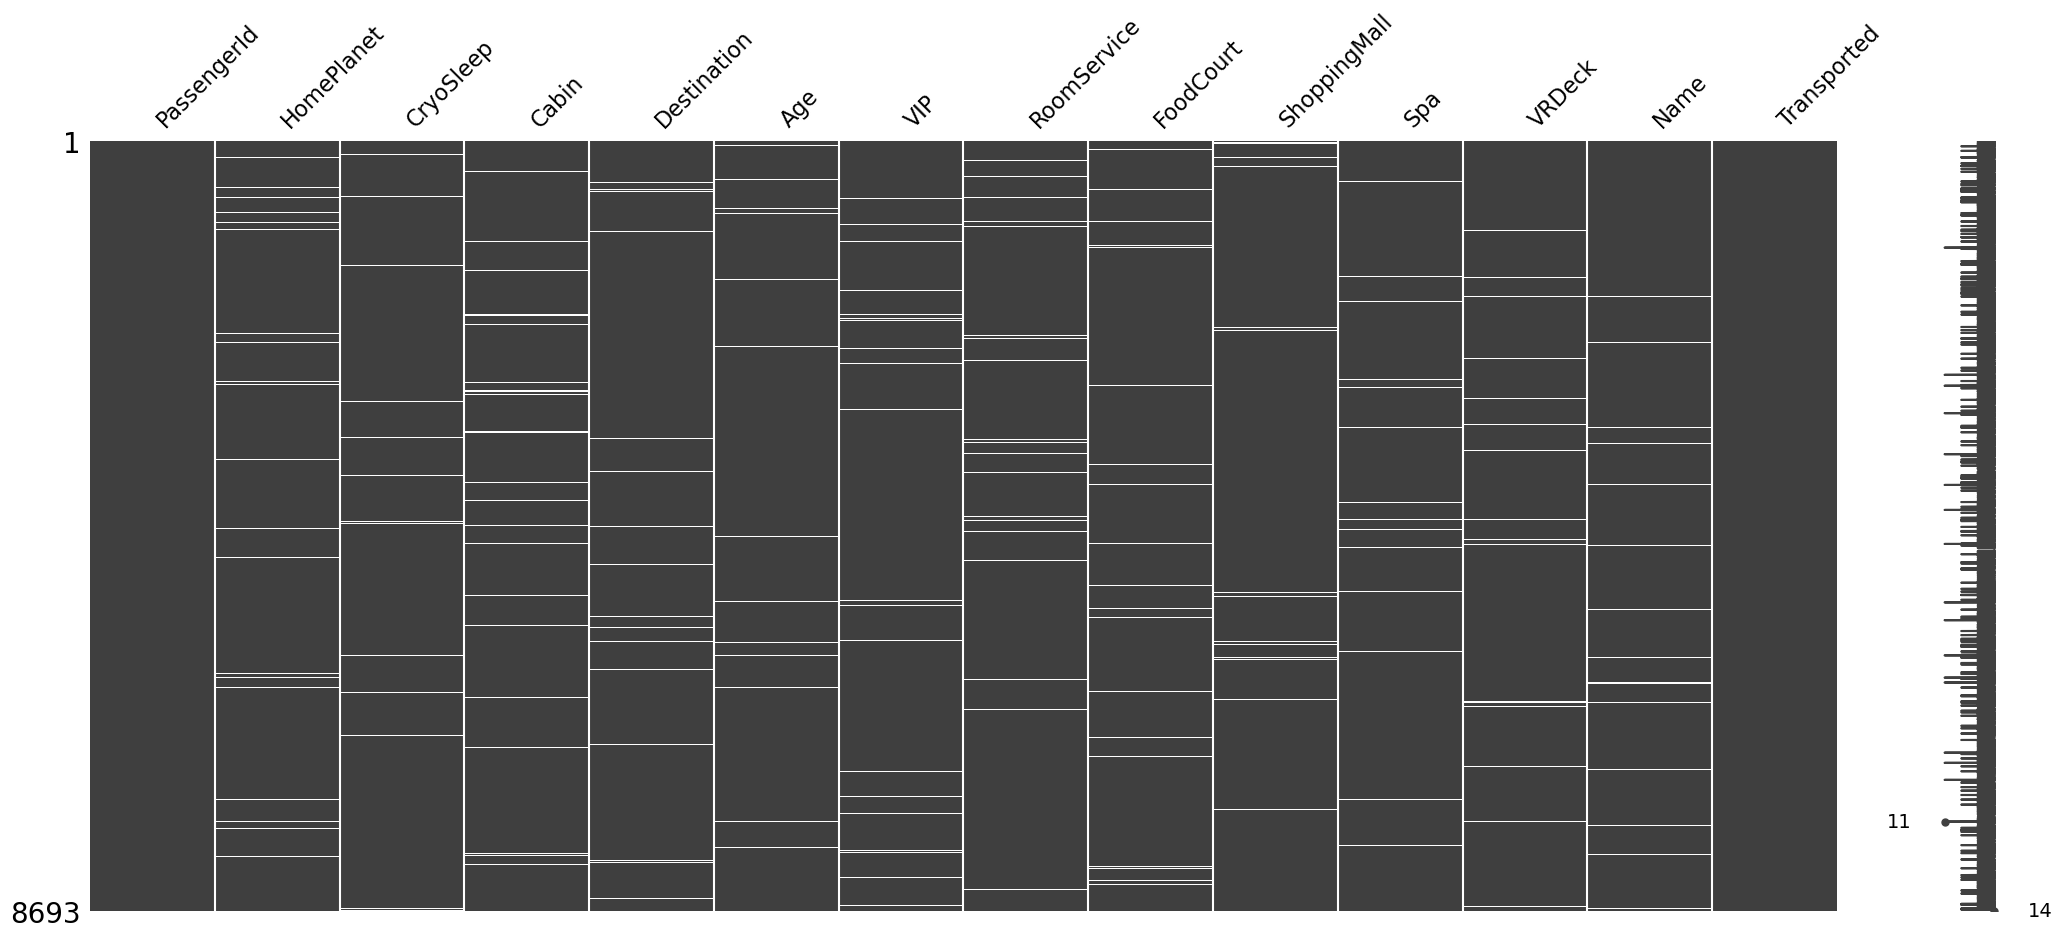

In [47]:
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)
msno.matrix(train)

In [33]:
print(train.isnull().sum())
test.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

EDA (데이터 분석) 및 시각화 

In [75]:
train['Transported'].value_counts()  #전체 승객 중 생존자 수

Transported
True     4378
False    4315
Name: count, dtype: int64

In [41]:
train[['Transported', 'VIP']].groupby(['Transported'], as_index=True).sum()

,VIP
Transported,
False,123
True,76


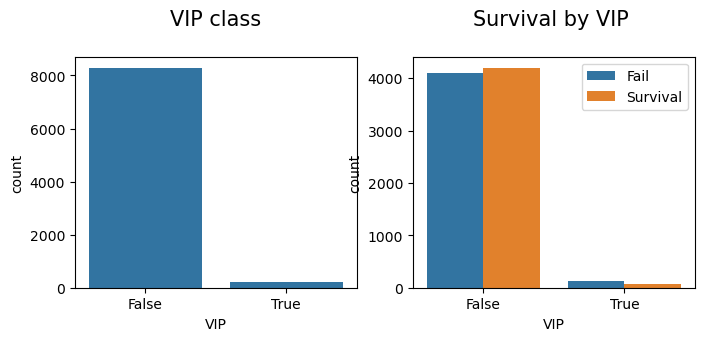

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].set_title("VIP class\n", size=15)
sns.countplot(x="VIP", data=train, ax=axes[0])

axes[1].set_title("Survival by VIP \n", size=15)
sns.countplot(x="VIP", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Fail', 'Survival'])

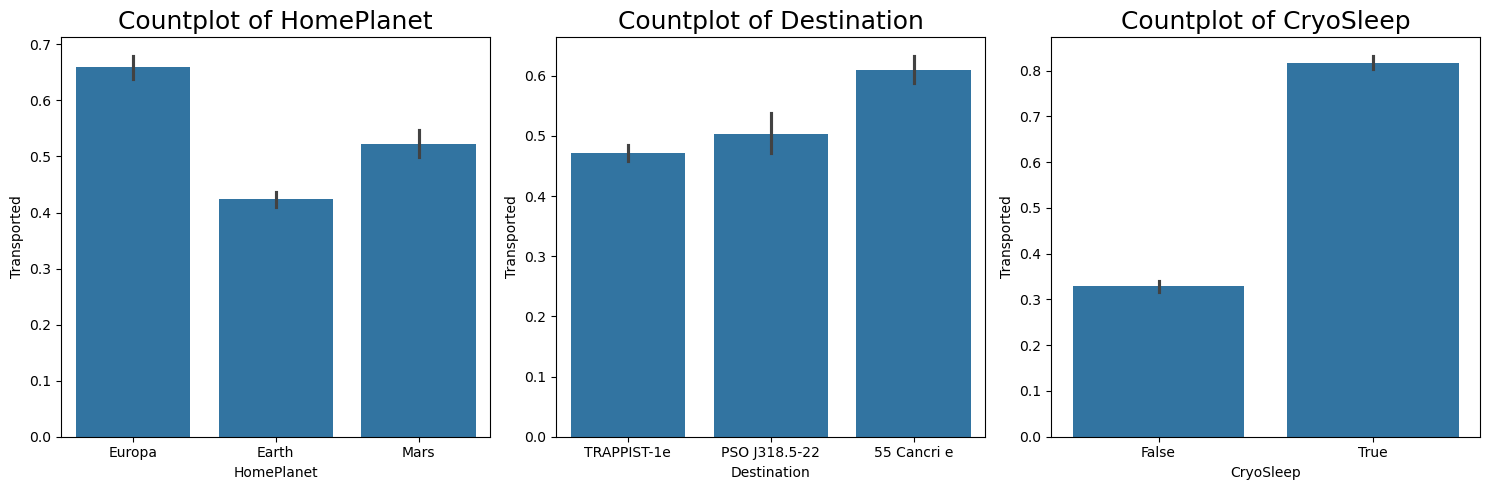

In [3]:
#피처별 생존율 그래프
fig, axes = plt.subplots(1,3, figsize=(15,5))     
cols = ['HomePlanet', 'Destination', 'CryoSleep']

for ax, col in zip(axes.flatten(), cols):
    sns.barplot(x=col, y='Transported', data=train, ax=ax)
    ax.set_title(f'Countplot of {col}', fontdict={'fontsize':18})
plt.tight_layout()
plt.show()

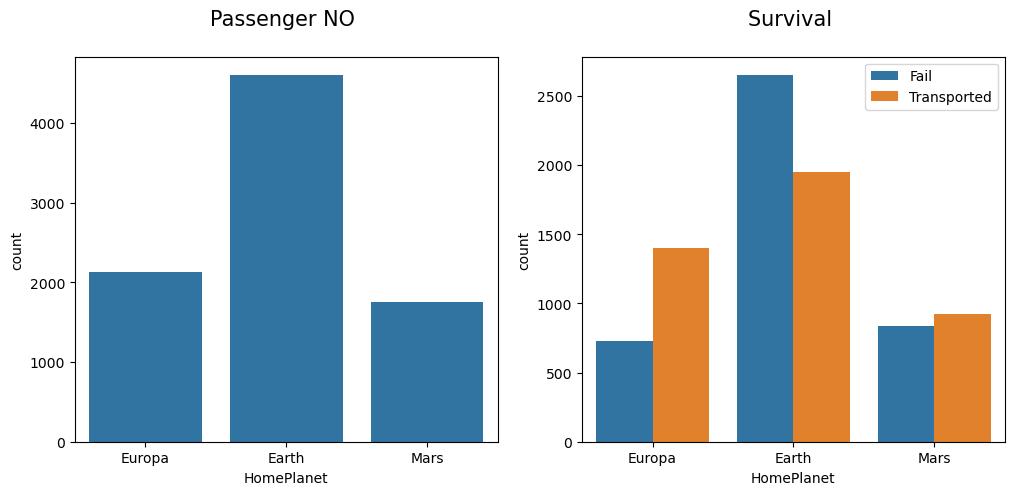

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Passenger NO \n", size=15)
sns.countplot(data=train, x='HomePlanet', ax=axes[0])

axes[1].set_title("Survival \n", size=15)
sns.countplot(x="HomePlanet", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Fail', 'Transported'])

Text(0.5, 1.0, 'Survival by HomePlanet')

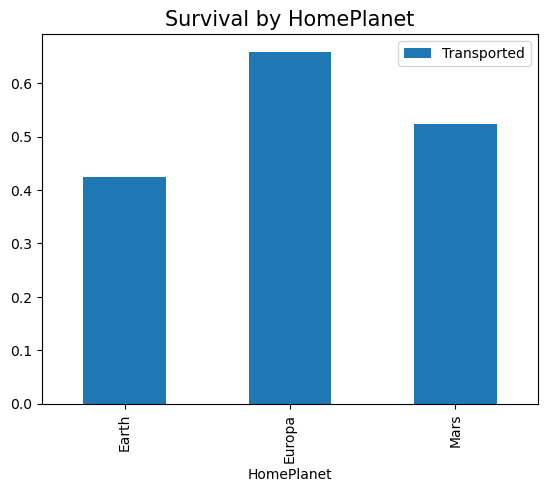

In [62]:
# HomePlanet별 생존률
sur = train[['HomePlanet', 'Transported']].groupby(['HomePlanet']).mean().plot.bar()
sur.set_title('Survival by HomePlanet', size=15)

<Axes: xlabel='Age', ylabel='Density'>

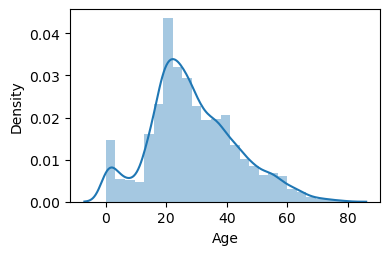

In [77]:
plt.figure(figsize=(4, 2.5))
sns.distplot(train['Age'], bins=25)

<Axes: xlabel='Age', ylabel='Density'>

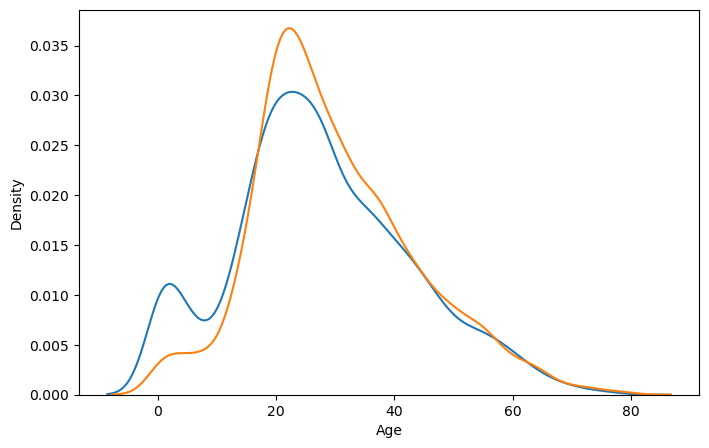

In [78]:
sur = train[train['Transported'] == 1]
dead = train[train['Transported'] == 0]

plt.figure(figsize=(8, 5))
sns.distplot(sur['Age'], bins=25, hist=False)
sns.distplot(dead['Age'], bins=25, hist=False)

데이터 전처리

1. Null 값 채우기
3. 피처 추가:  수
4. 카테고리 타입으로 변경: HomePlanet, Destination
5. 좌우 대칭이 아닌 그래프 데이터들의 정규분포화 작업
6. 불필요한 정보 칼럼 삭제

In [48]:
train_len = len(train)
data = pd.concat([train, test]).reset_index(drop=True)   # 전체 합치기
test_id = data['PassengerId'][train_len:].reset_index(drop=True)  # test의 passenger id 저장

#지출액 데이터 null data 처리
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data[expense_cols] = data[expense_cols].fillna(0)
data['expense_sum'] = data[expense_cols].sum(axis=1).astype(int)


#T/F 데이터 null data 처리
TF_cols = ['CryoSleep', 'VIP']
data[TF_cols] = data[TF_cols].fillna(False)
data[TF_cols] = data[TF_cols].replace({True: 1, False: 0})


#출발지, 목적지 데이터 전처리
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['HomePlanet'] = data['HomePlanet'].fillna('unknown')
data['HomePlanet'] = le.fit_transform(data['HomePlanet'].astype('category'))

mode_destination = data['Destination'].mode()[0] 
data['Destination'] = data['Destination'].fillna(mode_destination)
data['Destination'] = le.fit_transform(data['Destination'].astype('category'))


#Age 값 처리
mode_age = data['Age'].mode()[0]
data['Age'] = data['Age'].fillna(mode_age)


#Cabin 위치 처리
data['Cabin'] = data['Cabin'].fillna('un/0/un')
data['Cabin1'] = data['Cabin'].apply(lambda x: x.split('/')[0])
data['Cabin2'] = data['Cabin'].apply(lambda x: x.split('/')[1])
data['Cabin3'] = data['Cabin'].apply(lambda x: x.split('/')[2])
cab_cols = ['Cabin1', 'Cabin2', 'Cabin3']
# print(data['Cabin1'].head())
# print(data['Cabin3'].head())
data['Cabin1'] = le.fit_transform(data['Cabin1'].astype('category'))
data['Cabin2'] = le.fit_transform(data['Cabin2'].astype('category'))
data['Cabin3'] = le.fit_transform(data['Cabin3'].astype('category'))

#PassengerID 중 끝자리 가져오기: 혼자 or 일행(가족) 유무
data['passenger_grp'] = data['PassengerId'].apply(lambda x: x.split('_')[1])

# for col in data.columns:
#     if data[col].dtype == 'object':
#         data[col] = data[col].astype('category').cat.codes
# print(data.dtypes)

In [35]:
print(data['VIP'].unique())
print(data['CryoSleep'].unique())

[0 1]
[0 1]


In [49]:
del data['PassengerId']
del data['Name'] 
del data['Cabin'] 

train = data.iloc[:train_len]
test  = data.iloc[train_len:]

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = train[col].astype('category').cat.codes
        test[col]  = test[col].astype('category').cat.codes

print(train.dtypes)

HomePlanet         int64
CryoSleep          int64
Destination        int64
Age              float64
VIP                int64
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Transported         int8
expense_sum        int64
Cabin1             int64
Cabin2             int64
Cabin3             int64
passenger_grp       int8
dtype: object


<Axes: >

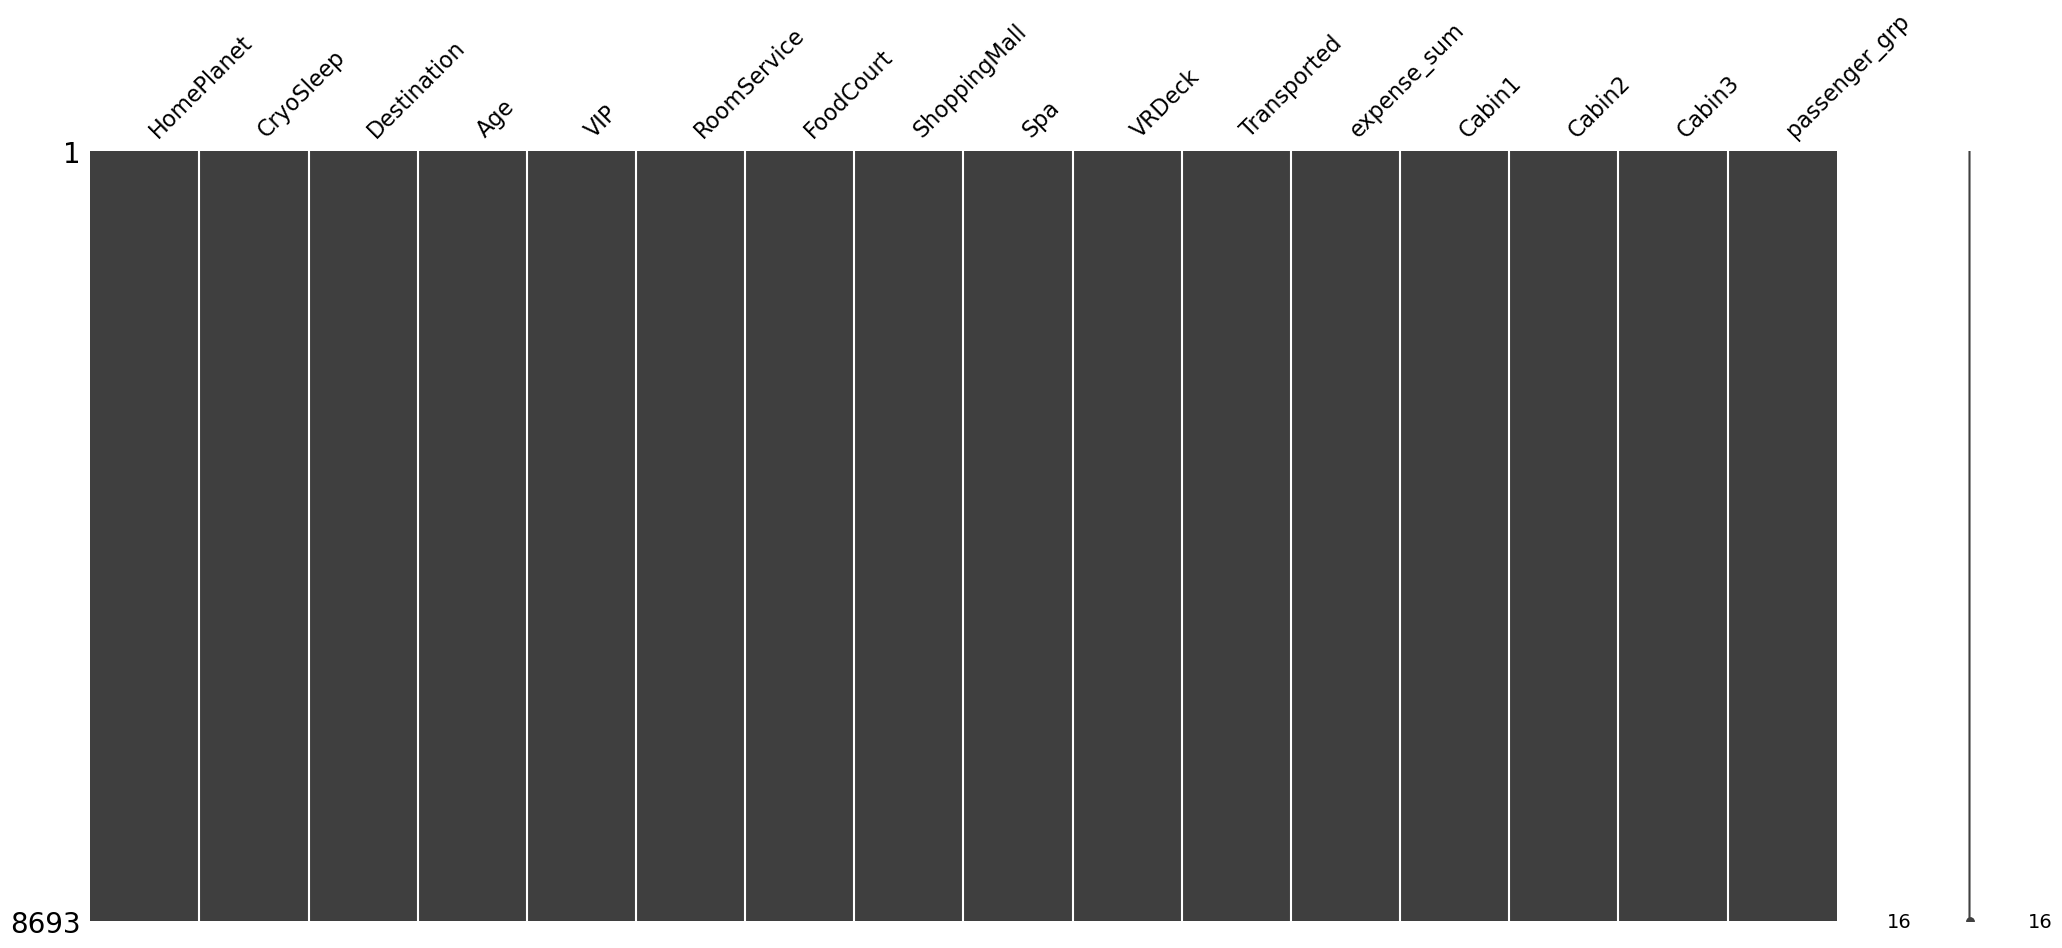

In [37]:
msno.matrix(train)

In [38]:

cor = train.corrwith(train['Transported']).sort_values(ascending=False)
print(cor)

Transported      1.000000
CryoSleep        0.460132
HomePlanet       0.107755
Cabin3           0.093319
passenger_grp    0.066390
FoodCourt        0.045583
Cabin2           0.018591
ShoppingMall     0.009391
VIP             -0.037261
Age             -0.073800
Destination     -0.108152
Cabin1          -0.109925
expense_sum     -0.199514
VRDeck          -0.204874
Spa             -0.218545
RoomService     -0.241124
dtype: float64


In [50]:
y = train['Transported']
del train['Transported']

y = y.astype(int)

In [13]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn import metrics 
from sklearn.model_selection import train_test_split

y = y.astype(int)
X_tr, X_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.2, random_state=2020)

model = RandomForestClassifier()
model.fit(X_tr, y_tr)
prediction = model.predict(X_vld)

print('{}명 중 {:.2f}% 정확도 추론'.format(y_vld.shape[0], 100 * metrics.accuracy_score(prediction, y_vld)))

1739명 중 80.22% 정확도 추론


학습 모델 함수 정의
- KNN, GBoost, XFBoost, RandomForest Classfier 모델 사용

In [51]:
from sklearn.model_selection import train_test_split
y = y.astype(int)

X_tr, X_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.2, random_state=2020)


from sklearn.metrics import mean_squared_error
from sklearn import metrics 
from sklearn.metrics import accuracy_score

from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
random_state = 2020

# 모델 설정 
knn      = KNeighborsClassifier(n_neighbors=5)
gboost   = GradientBoostingClassifier(random_state=random_state)
xgboost  = XGBClassifier(random_state=random_state)
lgbm     = LGBMClassifier(random_state=random_state)
rdforest = RandomForestClassifier(random_state=random_state)

voting = VotingClassifier(
    estimators=[
        ('knn',      knn),
        ('gboost',   gboost),
        ('xgboost',  xgboost),
        ('lgbm',     lgbm),
        ('rdforest', rdforest)
    ],
    voting='soft'  # 확률 평균 
)

voting.fit(X_tr, y_tr)
prediction = voting.predict(X_vld)

print(f"Accuracy: {accuracy_score(y_vld, voting.predict(X_vld)):.2f}")

[LightGBM] [Info] Number of positive: 3494, number of negative: 3460
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1894
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502445 -> initscore=0.009779
[LightGBM] [Info] Start training from score 0.009779
Accuracy: 0.81


In [58]:
print(set(X_train.columns))
set(test.columns)

{'Destination', 'FoodCourt', 'Spa', 'Age', 'Cabin2', 'Cabin1', 'HomePlanet', 'ShoppingMall', 'passenger_grp', 'expense_sum', 'VRDeck', 'RoomService', 'VIP', 'Cabin3', 'CryoSleep'}


{'Age',
 'Cabin1',
 'Cabin2',
 'Cabin3',
 'CryoSleep',
 'Destination',
 'FoodCourt',
 'HomePlanet',
 'RoomService',
 'ShoppingMall',
 'Spa',
 'Transported',
 'VIP',
 'VRDeck',
 'expense_sum',
 'passenger_grp'}

In [59]:
X_train = train.drop(['Transported'], axis=1, errors='ignore') 

voting.fit(X_train, y)

# voting.fit(train, y)
test_rv = test.drop(['Transported'], axis=1)
prediction = voting.predict(test_rv).astype(bool)

print(f"prediction 길이: {len(prediction)}")
print(f"test_id 길이   : {len(test_id)}")

[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1895
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495
prediction 길이: 4277
test_id 길이   : 4277


제출 파일 작성 

In [61]:

submission = pd.DataFrame({
    'PassengerId': test_id.reset_index(drop=True),
    'Transported': prediction.astype(bool)
})

submission.to_csv('~/work/kaggle_kakr_housing/space_titanic/Titanic_submission_v01.csv', index=False)
print(submission.head())


  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False


In [ ]:
submission.to_csv('submission.csv', index=False)
print(submission.shape)
print(submission['Transported'].value_counts())

In [ ]:
# 검증
from sklearn.metrics import accuracy_score
print(accuracy_score(y_vld, voting.predict(X_vld)))

# test 예측
prediction = voting.predict(test).astype(bool)



In [ ]:

y = y.astype(int)

X_tr, X_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.2, random_state=2020)

def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))


from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

random_state=2020        

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

Grid Search 설정
- 모델 평가 지표로 RMSE 적용

In [33]:
from sklearn.model_selection import GridSearchCV


def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    # GridSearchCV 모델로 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', \
                              cv=5, verbose=verbose, n_jobs=n_jobs)

    # 모델 fitting
    grid_model.fit(train, y)

    # 결과값 저장
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['score'] = score

    # RMSLE 값 계산 후 정렬
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    results = results.sort_values('RMSLE')

    return results

학습용 파라미터 설정
- grid search 설정: 트리의 횡적/종적 한도 , Leave 수량, Learning Rate 설정
- price 값에 log 함수 적용
- 최적 파라미터로 모델 재학습

In [27]:
param_grid = {
    'n_estimators': [700, 900, 1100],
    'max_depth': [8, 12, 15],
    'learning_rate': [0.06, 0.05, 0.04],
    'num_leaves' : [12, 15]
}

y_log = np.log1p(y)

model = LGBMRegressor(random_state=random_state)
param_gained = my_GridSearch(model, train, y_log, param_grid, verbose=10, n_jobs=5)

best = param_gained.iloc[0]
print(best)

# 최적 파라미터로 모델 재학습
model = LGBMRegressor(
    max_depth    = int(best['max_depth']),
    n_estimators = int(best['n_estimators']),
    learning_rate= best['learning_rate'],
    num_leaves   = int(best['num_leaves']),
    random_state = random_state
)
model.fit(train, y_log)



Fitting 5 folds for each of 54 candidates, totalling 270 fits

[LightGBM] [Info] Start training from score 13.050660
[CV 4/5; 72/81] END learning_rate=0.04, max_depth=12, n_estimators=900, num_leaves=18;, score=-0.026 total time=  10.7s
[CV 1/5; 74/81] START learning_rate=0.04, max_depth=15, n_estimators=500, num_leaves=15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3523
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 27
[LightGBM] [Info] Start training from score 13.050187
[CV 1/5; 74/81] END learning_rate=0.04, max_depth=15, n_estimators=500, num_leaves=15;, score=-0.026 total time=   5.5s
[CV 1/5; 75/81] START learning_rate=0.04, max_depth=15, n_estimators=500, num_leaves=18
[LightGBM] [Info] Auto-choosing row-wise multi-threading, th

,boosting_type,'gbdt'
,num_leaves,12
,max_depth,8
,learning_rate,np.float64(0.05)
,n_estimators,1100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
파일 저장용 함수 설정

In [28]:

def save_submission(model, train, y_log, test, model_name, rmsle=best['RMSLE'].round(4)):
    model.fit(train, y_log)
    # prediction = model.predict(test)
    # prediction = np.expm1(prediction)
    prediction = np .expm1(model.predict(test))
    data_dir = '~/work/kaggle_kakr_housing/data'
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    submission_csv_path = '{}/harry_submission_{}_ver_{}.csv'.format(data_dir, model_name, rmsle)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

print(param_gained.head())

    learning_rate  max_depth  n_estimators  num_leaves     score     RMSLE
22           0.05          8          1100          12 -0.025778  0.160556
28           0.05         12          1100          12 -0.025808  0.160649
34           0.05         15          1100          12 -0.025808  0.160649
53           0.04         15          1100          15 -0.025814  0.160666
20           0.05          8           900          12 -0.025818  0.160678


In [29]:
# 파일명 설정 및 저장 실행

save_submission(model, train, y_log, test, 'lgbm', rmsle='0.9')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3568
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 27
[LightGBM] [Info] Start training from score 13.048122
~/work/kaggle_kakr_housing/data/harry_submission_lgbm_ver_0.9.csv saved!


파일 제출 이후 화면 캡쳐